In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
covid = pd.read_excel(r'C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset\COVID.metadata.xlsx')
normal = pd.read_excel(r'C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset\Normal.metadata.xlsx')
lung = pd.read_excel(r'C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset\Lung_Opacity.metadata.xlsx')
pneumonia = pd.read_excel(r'C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset\Viral Pneumonia.metadata.xlsx')

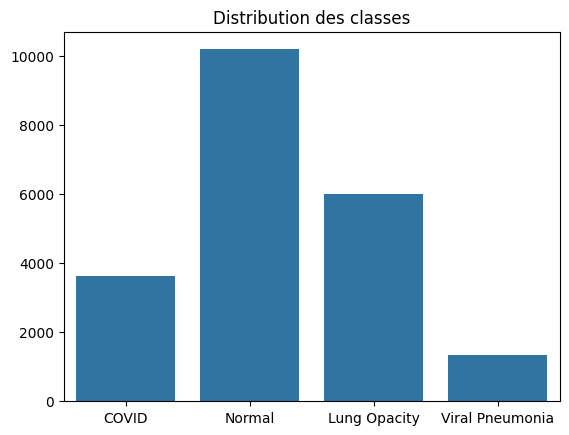

In [4]:
classes = {'COVID': len(covid), 'Normal': len(normal), 
           'Lung Opacity': len(lung), 'Viral Pneumonia': len(pneumonia)}
sns.barplot(x=list(classes.keys()), y=list(classes.values()))
plt.title("Distribution des classes")
plt.show()

## Distribution des classes

Le dataset présente un déséquilibre important entre les classes :
- Normal est très majoritaire (10 192 images)
- Viral Pneumonia est très minoritaire (1 345 images)

Ce déséquilibre devra être pris en compte lors de la modélisation 
(data augmentation, class weights).

## Source des images

Les images COVID proviennent de 4 sources différentes :
- 2473 images de PadChest
- 183 images d'une école médicale allemande
- 559 images de SIRM, Github, Kaggle
- 400 images d'une autre source Github

Le modèle pourrait apprendre des artefacts techniques 
propres à chaque source plutôt que les caractéristiques médicales du Covid.

Normalisation des images en pre-processing ?

In [6]:
def get_source(url):
    if 'sirm' in str(url): return 'SIRM'
    elif 'github' in str(url): return 'Github'
    elif 'kaggle' in str(url): return 'Kaggle'
    elif 'padchest' in str(url) or 'bimcv' in str(url): return 'PadChest'
    elif 'figshare' in str(url): return 'Figshare'
    else: return 'Autre'

covid['source'] = covid['URL'].apply(get_source)
covid['source'].value_counts()

source
PadChest    2474
Github       765
Autre        258
SIRM         119
Name: count, dtype: int64

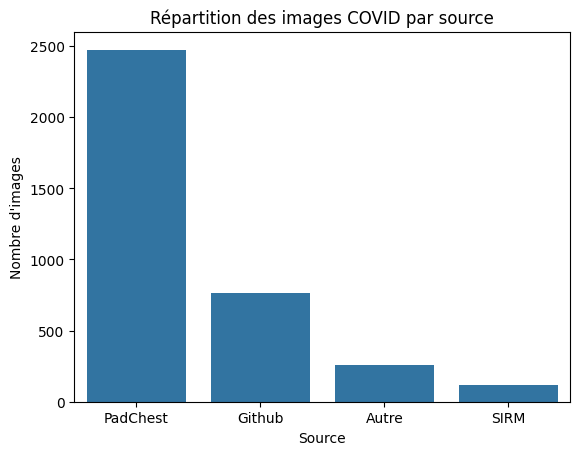

In [ ]:
sns.barplot(x=covid['source'].value_counts().index, 
            y=covid['source'].value_counts().values)
plt.title("Répartition des images COVID par source")
plt.xlabel("Source")
plt.ylabel("Nombre d'images")
plt.show()

In [10]:
import cv2

base = r"C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset"

img = cv2.imread(base + r"\COVID\images\COVID-1.png")
mask = cv2.imread(base + r"\COVID\masks\COVID-1.png")

print("Image :", img.shape)
print("Masque :", mask.shape)

Image : (299, 299, 3)
Masque : (256, 256, 3)
